# Air Quality Index Prediction
This project aims to develop a predictive model for estimating air quality index (AQI) based on various environmental factors.

## Importing Required Libraries
We start by importing essential libraries for data manipulation, visualization, and model training.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Loading and Exploring the Dataset
We load the dataset and perform initial exploration to understand its structure and characteristics.

In [3]:
# Load Dataset
file_path = "city_day.csv"  #https://www.kaggle.com/code/anjusunilkumar/air-quality-index-prediction?select=city_day.csv
df = pd.read_csv(file_path)

In [5]:
#Display Dataset
df

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,Visakhapatnam,2020-06-27,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,0.73,41.0,Good
29527,Visakhapatnam,2020-06-28,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,0.38,70.0,Satisfactory
29528,Visakhapatnam,2020-06-29,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,0.00,68.0,Satisfactory
29529,Visakhapatnam,2020-06-30,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,0.00,0.00,54.0,Satisfactory


In [7]:
# Display basic info about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


## Data Preprocessing
This step involves handling missing values, encoding categorical features, and normalizing numerical features.

In [9]:
# Che+ck the total null values
df.isnull().sum()

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

In [41]:
# Handling missing values
# Drop rows where AQI is missing, as it's our target variable
df = df.dropna(subset=['AQI'])
print(len(df))
df.isnull().sum()

24850


PM2.5      0
PM10       0
NO         0
NO2        0
NOx        0
NH3        0
CO         0
SO2        0
O3         0
Benzene    0
Toluene    0
Xylene     0
AQI        0
dtype: int64

In [27]:
# Fill missing values only in numeric columns with their respective column means
df.fillna(df.select_dtypes(include=['number']).mean(), inplace=True)

In [29]:
# Drop non-numeric and irrelevant columns
drop_columns = ['City', 'Date', 'AQI_Bucket']  # 'City' and 'Date' are categorical, 'AQI_Bucket' is redundant
df = df.drop(columns=drop_columns)

In [99]:
# Define target (dependent variable) and features (independent variables)
target = 'AQI'
features = [col for col in df.columns if col != target]  # All columns except AQI
print(features)

X = df[features]  # Features dataset
y = df[target]  # Target variable

['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']


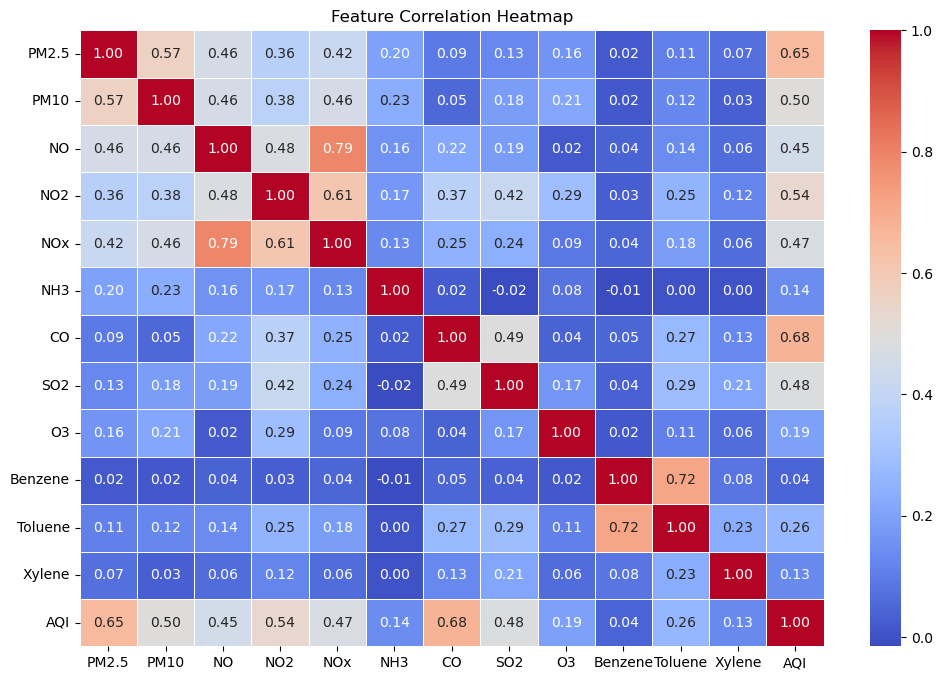

In [101]:
# Select only numerical columns for correlation
num_df = df.select_dtypes(include=['number'])  # Keep only numeric columns

# Compute correlation matrix
corr_matrix = num_df.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

## Splitting Data into Training and Testing Sets
We divide the dataset into training and test sets to evaluate model performance.

In [103]:
# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Feature Scaling

In [105]:
# Feature Scaling
# Standardize the dataset to have zero mean and unit variance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Training models

In [117]:
from sklearn.ensemble import GradientBoostingRegressor

# Initialize and define models to be tested
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

In [119]:
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2 Score': r2}
    print(f"{name} Performance:\nMAE: {mae:.2f}, RMSE: {rmse:.2f}, R2 Score: {r2:.2f}\n")

# Convert results to DataFrame for better visualization
results_df = pd.DataFrame(results).T
print(results_df)

Linear Regression Performance:
MAE: 31.20, RMSE: 59.11, R2 Score: 0.81

Random Forest Performance:
MAE: 20.59, RMSE: 40.48, R2 Score: 0.91

Gradient Boosting Performance:
MAE: 23.71, RMSE: 43.81, R2 Score: 0.90

                         MAE       RMSE  R2 Score
Linear Regression  31.203327  59.108362  0.809197
Random Forest      20.591788  40.480720  0.910508
Gradient Boosting  23.714891  43.814207  0.895162


# Model Performance Comparison

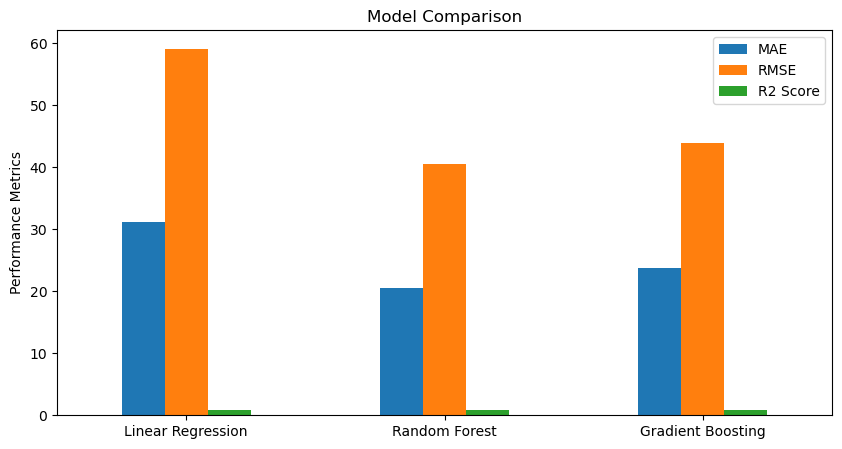

In [121]:
# Plot model performance
results_df.plot(kind='bar', figsize=(10, 5))
plt.title("Model Comparison")
plt.ylabel("Performance Metrics")
plt.xticks(rotation=0)
plt.show()

# Feature Importance Analysis

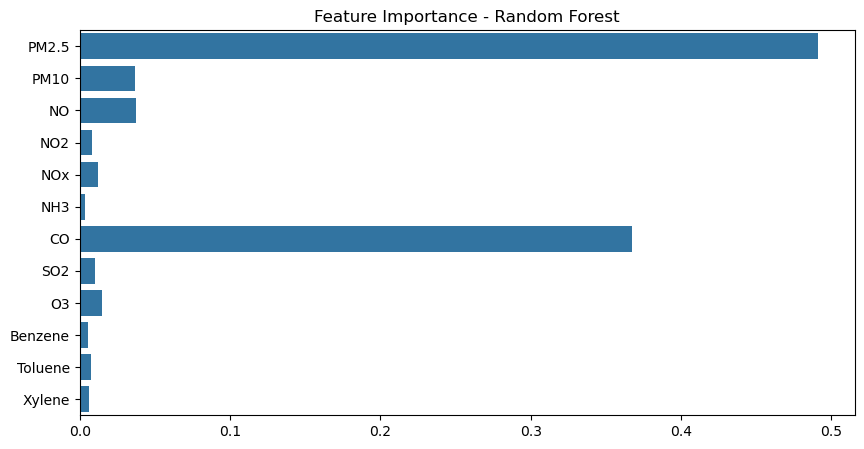

In [125]:
# Feature Importance Plot (For Random Forest)
feature_importance = models["Random Forest"].feature_importances_
plt.figure(figsize=(10, 5))
sns.barplot(x=feature_importance, y=features)
plt.title("Feature Importance - Random Forest")
plt.show()

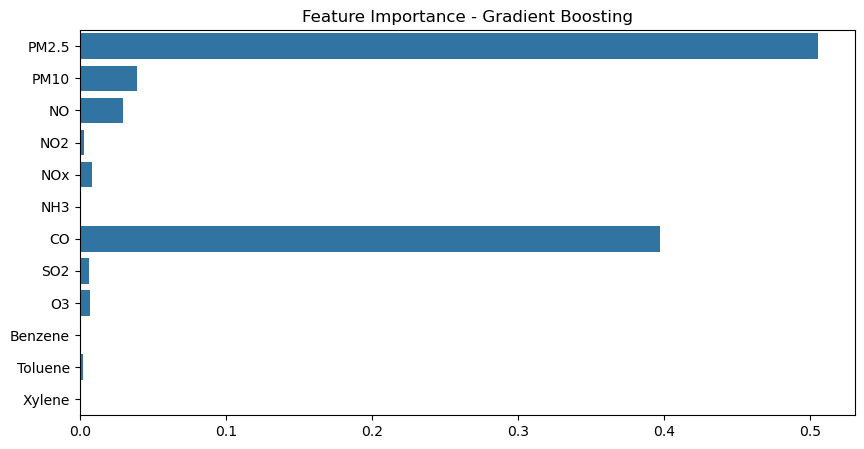

In [123]:
# Feature Importance Plot (For Gradient Boosting)
feature_importance = models["Gradient Boosting"].feature_importances_
plt.figure(figsize=(10, 5))
sns.barplot(x=feature_importance, y=features)
plt.title("Feature Importance - Gradient Boosting")
plt.show()

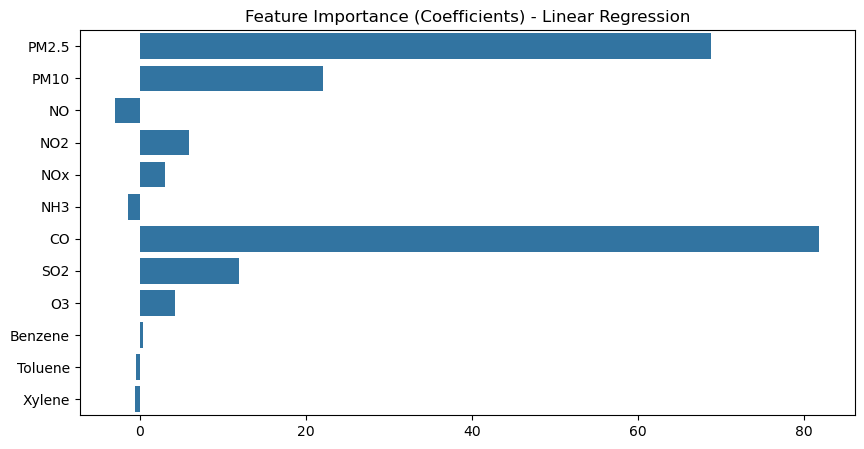

In [129]:
# Feature Importance Plot (For Linear Regression)
feature_importance = models["Linear Regression"].coef_
plt.figure(figsize=(10, 5))
sns.barplot(x=feature_importance, y=features)
plt.title("Feature Importance (Coefficients) - Linear Regression")
plt.show()

In [169]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Define AQI bucket boundaries
def aqi_to_bucket(aqi):
    if aqi <= 50:
        return 'Good'
    elif aqi <= 100:
        return 'Satisfactory'
    elif aqi <= 200:
        return 'Moderate'
    elif aqi <= 300:
        return 'Poor'
    elif aqi <= 400:
        return 'Very Poor'
    else:
        return 'Severe'

def evaluate_classification(y_test, y_pred, model_name):
    # Convert continuous predictions to categories
    y_test_buckets = y_test.apply(aqi_to_bucket)
    y_pred_buckets = pd.Series(y_pred).apply(aqi_to_bucket)

    # Per-class metrics
    labels = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
    per_class_recall = recall_score(y_test_buckets, y_pred_buckets, labels=labels, average=None, zero_division=0)
    per_class_f1 = f1_score(y_test_buckets, y_pred_buckets, labels=labels, average=None, zero_division=0)
    per_class_precision = precision_score(y_test_buckets, y_pred_buckets, labels=labels, average=None, zero_division=0)

    # Overall (weighted) metrics
    accuracy = accuracy_score(y_test_buckets, y_pred_buckets)
    overall_precision = precision_score(y_test_buckets, y_pred_buckets, labels=labels, average='weighted', zero_division=0)
    overall_recall = recall_score(y_test_buckets, y_pred_buckets, labels=labels, average='weighted', zero_division=0)
    overall_f1 = f1_score(y_test_buckets, y_pred_buckets, labels=labels, average='weighted', zero_division=0)

    # Display
    print("=" * 50)
    print(f"    Performance Analysis - {model_name}")
    print("=" * 50)
    print(f"\n{'Category':<18} {'Recall':<10} {'F1':<10} {'Precision':<10}")
    print("-" * 48)
    for i, label in enumerate(labels):
        print(f"{label:<18} {per_class_recall[i]:<10.2f} {per_class_f1[i]:<10.2f} {per_class_precision[i]:<10.2f}")
    print("-" * 48)
    print(f"{'OVERALL':<18} {overall_recall:<10.2f} {overall_f1:<10.2f} {overall_precision:<10.2f}")
    print(f"\n        Overall Accuracy: {accuracy:.2f}")
    print("=" * 50)

    # Confusion Matrix
    cm = confusion_matrix(y_test_buckets, y_pred_buckets, labels=labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Optimizing Models training and results

### Gradient Boosting

In [131]:
# Hyperparameter Tuning - Gradient Boosting
tuning_params = {
    'n_estimators': [50, 100],
    'learning_rate': [0.1, 0.2],
    'max_depth': [3, 5]
}

Best Gradient Boosting Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50}
Optimized Gradient Boosting Performance:
MAE: 21.78, RMSE: 41.90, R2 Score: 0.90
Predicted AQI values: [103.20493745 213.7732239  102.2217613  120.33737332  78.87255412]


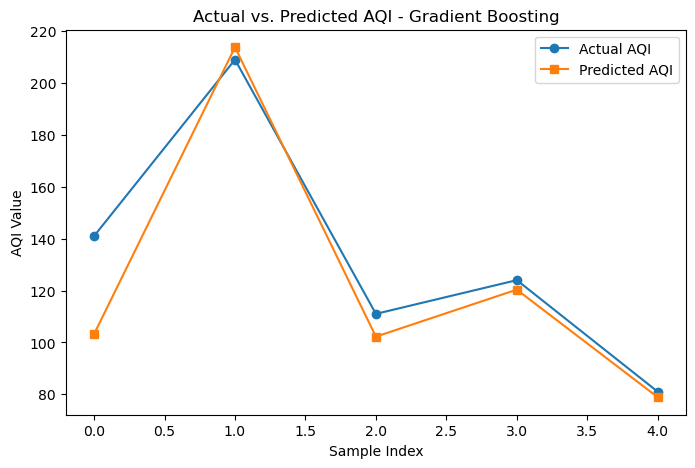

In [141]:
grid_search = GridSearchCV(GradientBoostingRegressor(), tuning_params, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)
print(f"Best Gradient Boosting Parameters: {grid_search.best_params_}")

# Train the best model with optimized parameters
best_gb = GradientBoostingRegressor(
    learning_rate=0.2,
    max_depth=5,
    n_estimators=100,
    random_state=42
)
best_gb.fit(X_train_scaled, y_train)
y_pred_gb = best_gb.predict(X_test_scaled)

# Evaluate the optimized model
mae = mean_absolute_error(y_test, y_pred_gb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2 = r2_score(y_test, y_pred_gb)
print(f"Optimized Gradient Boosting Performance:\nMAE: {mae:.2f}, RMSE: {rmse:.2f}, R2 Score: {r2:.2f}")

# Predict on first 5 test samples
new_data = X_test_scaled[:5]
predictions = best_gb.predict(new_data)
print("Predicted AQI values:", predictions)

# Save predictions to CSV
#pred_df = pd.DataFrame({'Predicted_AQI': predictions})
#pred_df.to_csv("aqi_predictions.csv", index=False)
#print("Predictions saved to aqi_predictions.csv")

# Plot Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.plot(y_test[:5].values, label="Actual AQI", marker='o')
plt.plot(predictions, label="Predicted AQI", marker='s')
plt.xlabel("Sample Index")
plt.ylabel("AQI Value")
plt.title("Actual vs. Predicted AQI - Gradient Boosting")
plt.legend()
plt.show()

    Performance Analysis - Gradient Boosting

Category           Recall     F1         Precision 
------------------------------------------------
Good               0.48       0.61       0.85      
Satisfactory       0.82       0.82       0.81      
Moderate           0.83       0.81       0.79      
Poor               0.71       0.68       0.66      
Very Poor          0.72       0.74       0.76      
Severe             0.80       0.82       0.84      
------------------------------------------------
OVERALL            0.78       0.78       0.78      

        Overall Accuracy: 0.78


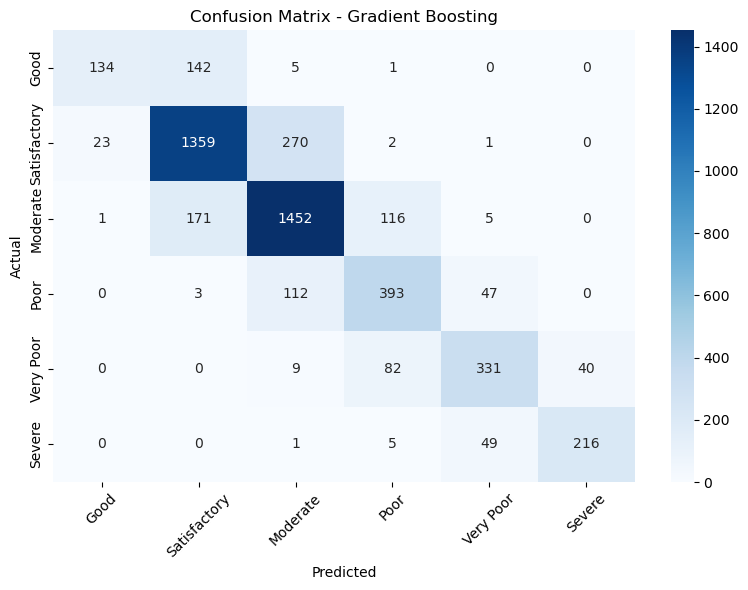

In [171]:
# --- Accuracy, F1, Recall, Precsion scores. Gradient Boosting ---
evaluate_classification(y_test, y_pred_gb, "Gradient Boosting")

### Random Forest

In [157]:
# Hyperparameter Tuning - Random Forest 
rf_tuning_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10]
}

Best Random Forest Parameters: {'max_depth': 10, 'n_estimators': 200}
Optimized Random Forest Performance:
MAE: 22.11, RMSE: 41.06, R2 Score: 0.91
Predicted AQI values: [ 94.61352188 215.66088535 105.02962598 117.60466052  74.26607811]


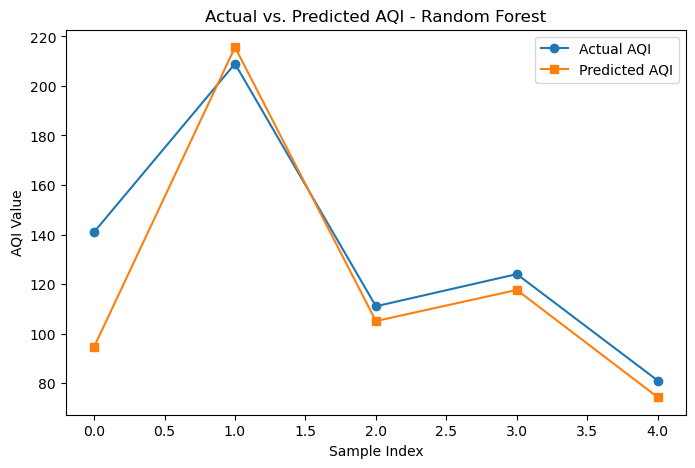

In [159]:
# --- Random Forest ---
grid_search_rf = GridSearchCV(RandomForestRegressor(random_state=42), rf_tuning_params, cv=3, scoring='r2', n_jobs=-1)
grid_search_rf.fit(X_train_scaled, y_train)
print(f"Best Random Forest Parameters: {grid_search_rf.best_params_}")

best_rf = RandomForestRegressor(
    max_depth=grid_search_rf.best_params_.get('max_depth', 10),
    n_estimators=grid_search_rf.best_params_.get('n_estimators', 100),
    random_state=42
)
best_rf.fit(X_train_scaled, y_train)
y_pred_rf = best_rf.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)
print(f"Optimized Random Forest Performance:\nMAE: {mae:.2f}, RMSE: {rmse:.2f}, R2 Score: {r2:.2f}")

new_data = X_test_scaled[:5]
predictions_rf = best_rf.predict(new_data)
print("Predicted AQI values:", predictions_rf)

plt.figure(figsize=(8, 5))
plt.plot(y_test[:5].values, label="Actual AQI", marker='o')
plt.plot(predictions_rf, label="Predicted AQI", marker='s')
plt.xlabel("Sample Index")
plt.ylabel("AQI Value")
plt.title("Actual vs. Predicted AQI - Random Forest")
plt.legend()
plt.show()

    Performance Analysis - Random Forest

Category           Recall     F1         Precision 
------------------------------------------------
Good               0.29       0.44       0.86      
Satisfactory       0.84       0.81       0.78      
Moderate           0.82       0.80       0.78      
Poor               0.68       0.67       0.65      
Very Poor          0.70       0.74       0.77      
Severe             0.81       0.83       0.86      
------------------------------------------------
OVERALL            0.77       0.76       0.77      

        Overall Accuracy: 0.77


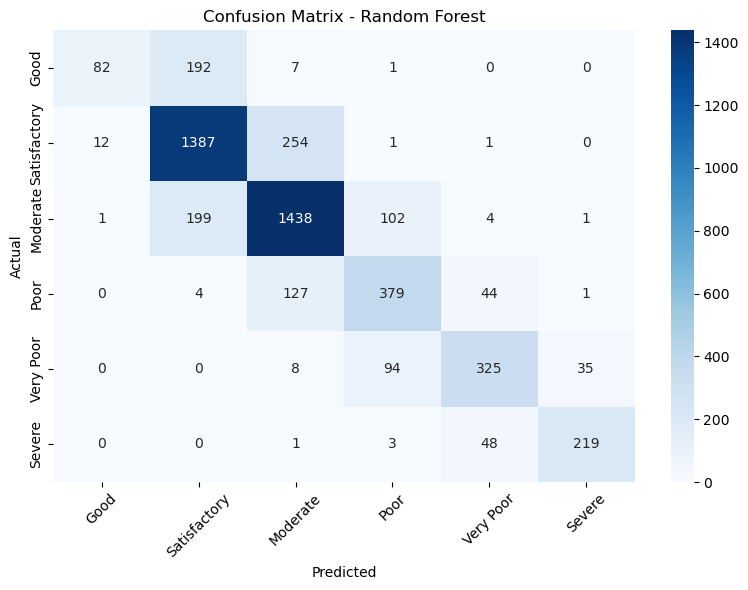

In [173]:
# --- Accuracy, F1, Recall, Precsion scores. Random Forest ---
evaluate_classification(y_test, y_pred_rf, "Random Forest")

### Linear Regression

Linear Regression Performance:
MAE: 31.20, RMSE: 59.11, R2 Score: 0.81
Predicted AQI values: [114.05122911 200.71997899 116.16856349 126.07120008  85.6955432 ]


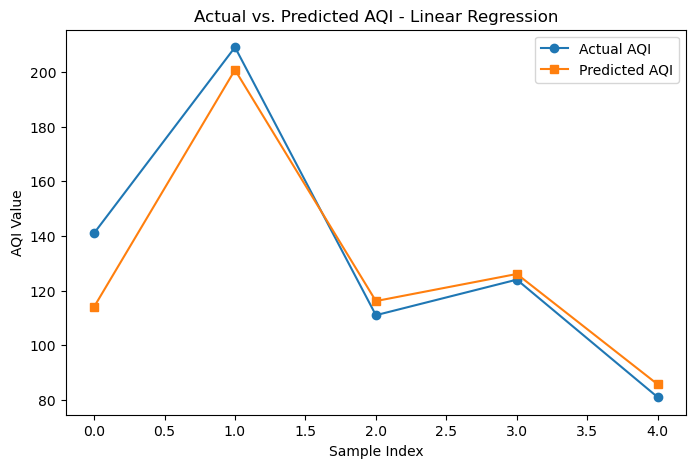

In [161]:
# --- Linear Regression ---
from sklearn.linear_model import LinearRegression

# Note: Linear Regression has no hyperparameters to tune, so no GridSearchCV needed
best_lr = LinearRegression()
best_lr.fit(X_train_scaled, y_train)
y_pred_lr = best_lr.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)
print(f"Linear Regression Performance:\nMAE: {mae:.2f}, RMSE: {rmse:.2f}, R2 Score: {r2:.2f}")

new_data = X_test_scaled[:5]
predictions_lr = best_lr.predict(new_data)
print("Predicted AQI values:", predictions_lr)

plt.figure(figsize=(8, 5))
plt.plot(y_test[:5].values, label="Actual AQI", marker='o')
plt.plot(predictions_lr, label="Predicted AQI", marker='s')
plt.xlabel("Sample Index")
plt.ylabel("AQI Value")
plt.title("Actual vs. Predicted AQI - Linear Regression")
plt.legend()
plt.show()

    Performance Analysis - Linear Regression

Category           Recall     F1         Precision 
------------------------------------------------
Good               0.39       0.47       0.60      
Satisfactory       0.66       0.71       0.78      
Moderate           0.86       0.75       0.67      
Poor               0.60       0.55       0.51      
Very Poor          0.39       0.49       0.69      
Severe             0.76       0.77       0.77      
------------------------------------------------
OVERALL            0.69       0.68       0.69      

        Overall Accuracy: 0.69


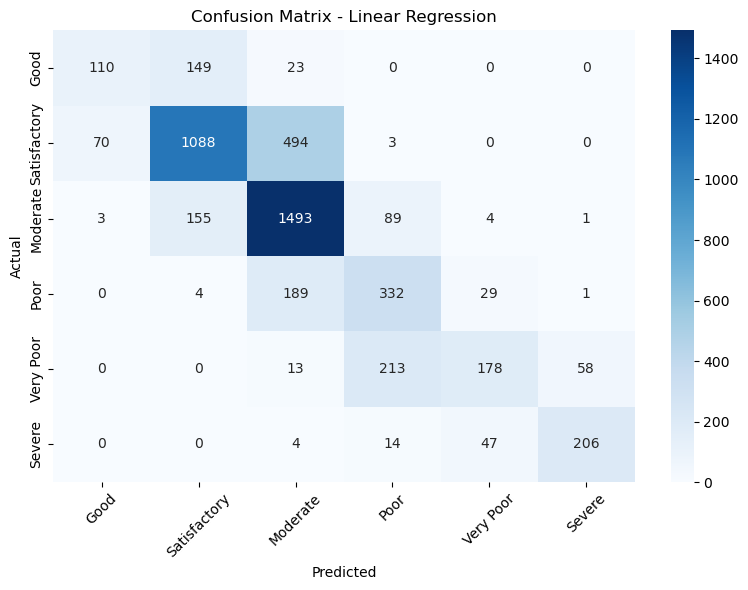

In [177]:
# --- Accuracy, F1, Recall, Precsion scores. Linear Regression ---
evaluate_classification(y_test, y_pred_lr, "Linear Regression")

## Saving the best model

In [ ]:
# Save the best model
#import joblib
#joblib.dump(models["XGBoost"], "best_aqi_model.pkl")

## Downloading the Saved Model

In [ ]:
#from google.colab import files
#files.download("best_aqi_model.pkl")